<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/Analysis/(Analysis)Force_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [2]:
# 1. 데이터 로드 로직
file_names = ['P7_Exp2_SameDifferent_Discrimination.csv',
              'P8_Exp2_SameDifferent_Discrimination.csv',
              'P9_Exp2_SameDifferent_Discrimination.csv'] # 확장자 .csv 확인 필요
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        # IsCorrect가 문자열 'true'/'false'일 경우 숫자로 변환
        if temp_df['IsCorrect'].dtype == 'object':
            temp_df['IsCorrect'] = temp_df['IsCorrect'].str.lower().map({'true': 1, 'false': 0})
        else:
            temp_df['IsCorrect'] = temp_df['IsCorrect'].astype(int)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")


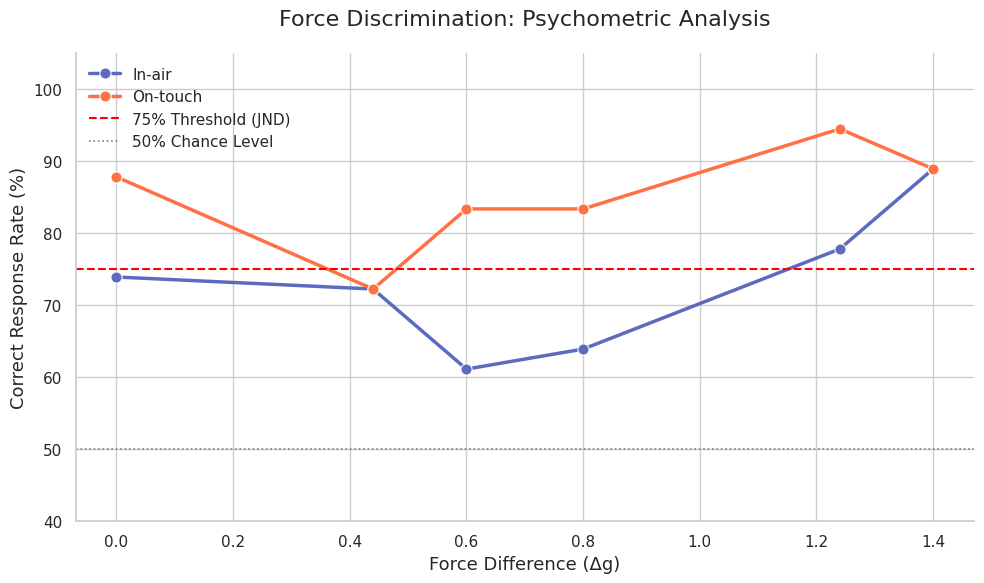

### Overall Accuracy by Condition ###
Condition
In-air      73.333333
On-touch    86.111111
Name: IsCorrect_Num, dtype: float64


In [3]:
for file in file_names:
    temp_df = pd.read_csv(file)
    data_list.append(temp_df)

df = pd.concat(data_list, ignore_index=True)

# IsCorrect 컬럼을 불리언/숫자로 변환 (문자열 'true'/'false' 대응)
df['IsCorrect_Num'] = df['IsCorrect'].map({'true': 1, 'false': 0, True: 1, False: 0})

# 2. 자극 간의 '힘의 차이(Force Difference)' 계산
def get_force_diff(row):
    f1 = float(row['FirstStim'].replace('g', ''))
    f2 = float(row['SecondStim'].replace('g', ''))
    return abs(f1 - f2)

df['ForceDiff'] = df.apply(get_force_diff, axis=1)

# 3. 조건별/자극차이별 정답률 계산
# Different 시행(ForceDiff > 0)에 대해서만 분석하거나 전체 정확도를 볼 수 있습니다.
# 여기서는 '자극의 차이가 커질 때 얼마나 잘 맞추는가'를 보기 위해 ForceDiff별로 그룹화합니다.
accuracy_summary = df.groupby(['Condition', 'ForceDiff'])['IsCorrect_Num'].mean().reset_index()
accuracy_summary['Accuracy_Pct'] = accuracy_summary['IsCorrect_Num'] * 100

# 4. 시각화 (Psychometric Curve 형태)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 선 그래프 (각 조건별 정답률 변화)
sns.lineplot(data=accuracy_summary, x='ForceDiff', y='Accuracy_Pct', hue='Condition',
             marker='o', markersize=8, linewidth=2.5, palette=['#5C6BC0', '#FF7043'])

# 75% Threshold 가이드라인 (중요!)
plt.axhline(75, color='red', linestyle='--', linewidth=1.5, label='75% Threshold (JND)')
# 50% Chance Level (찍기 수준)
plt.axhline(50, color='gray', linestyle=':', linewidth=1.2, label='50% Chance Level')

# 그래프 디테일 설정
plt.title('Force Discrimination: Psychometric Analysis', fontsize=16, pad=20)
plt.xlabel('Force Difference (Δg)', fontsize=13)
plt.ylabel('Correct Response Rate (%)', fontsize=13)
plt.ylim(40, 105)
plt.legend(frameon=False)
sns.despine()

plt.tight_layout()
plt.show()

# 5. 통계 요약 출력
overall_acc = df.groupby('Condition')['IsCorrect_Num'].mean() * 100
print("### Overall Accuracy by Condition ###")
print(overall_acc)

In [4]:
# 2. 데이터 전처리
def clean_force(x):
    if isinstance(x, str):
        return float(x.replace('g', ''))
    return x

df['RefVal'] = df['Reference'].apply(clean_force)
df['CompVal'] = df['Comparison'].apply(clean_force)
df['WeberRatio'] = (df['CompVal'] - df['RefVal']) / df['RefVal'] # (ΔF / F)
# IsCorrect가 문자열 'true'/'false'일 경우를 대비해 불리언/정수형 변환
df['IsCorrect'] = df['IsCorrect'].map({'true': 1, 'false': 0, True: 1, False: 0})

KeyError: 'Reference'

In [ ]:
# 3. 주요 지표 시각화 (Accuracy)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# (왼쪽) 조건별 정확도
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Condition', y='IsCorrect', palette='muted', capsize=.1)
plt.axhline(0.5, ls='--', color='gray', label='Chance (50%)')
plt.title('Overall Accuracy by Condition')
plt.ylim(0, 1.1)
plt.legend()

# (오른쪽) 구역(Region) 및 조건별 정확도
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Region', y='IsCorrect', hue='Condition', order=['A', 'B', 'C'], palette='pastel')
plt.title('Accuracy by Region & Condition')
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
if data_list:
    df_merged = pd.concat(data_list, ignore_index=True)

    # 2. 박스플롯을 위한 데이터 가공
    # 각 조건(Condition) 내에서 '자극 쌍(Reference, Comparison)'별 평균 정답률을 계산합니다.
    # 이렇게 해야 0~1 사이의 다양한 정답률 값이 생성되어 '박스'가 그려집니다.
    plot_data = df_merged.groupby(['Condition', 'Reference', 'Comparison'])['IsCorrect'].mean().reset_index()

    plt.figure(figsize=(10, 6))

    # 3. 박스플롯 (분포 표시)
    sns.boxplot(data=plot_data, x='Condition', y='IsCorrect',
                palette='Set3', width=0.4, showfliers=False)

    # 4. 스트립플롯 (모든 데이터 포인트를 점으로 표시)
    # 개별 자극 쌍들의 정답률이 점으로 찍힙니다.
    sns.stripplot(data=plot_data, x='Condition', y='IsCorrect',
                  color='black', size=7, jitter=True, alpha=0.6)

    # 5. 그래프 꾸미기
    plt.title('Force Discrimination Accuracy Distribution', fontsize=16, pad=20)
    plt.ylabel('Mean Accuracy (0.0 ~ 1.0)', fontsize=12)
    plt.xlabel('Condition', fontsize=12)
    plt.axhline(0.5, ls='--', color='red', alpha=0.3, label='Chance Level (50%)') # 무작위 정답선
    plt.ylim(-0.05, 1.1)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()
else:
    print("분석할 데이터가 없습니다. 파일명을 확인해 주세요.")

### x축이 pair되게끔

In [ ]:
df_merged = pd.concat(data_list, ignore_index=True)

# 2. X축을 위한 'Pair' 컬럼 생성 (예: "0.07-0.16")
df_merged['Pair'] = df_merged['Reference'].str.replace('g','') + " vs " + df_merged['Comparison'].str.replace('g','')

# 3. 분석을 위해 그룹화 (컨디션, 쌍, 구역별 평균 정답률 계산)
# 각 점(Scatter)은 특정 Region의 정답률이 됩니다.
plot_df = df_merged.groupby(['Condition', 'Pair', 'Region'])['IsCorrect'].mean().reset_index()

#기존 그룹화 데이터에 퍼센테이지 컬럼 추가
plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100

print("완")

In [ ]:
import matplotlib.ticker as mtick

# 스타일 설정
conditions = plot_df['Condition'].unique()

for cond in conditions:
    plt.figure(figsize=(12, 7))

    cond_data = plot_df[plot_df['Condition'] == cond]

    # [A] 박스플롯: 전체적인 분포(중앙값, 사분위수) 표시
    sns.boxplot(data=cond_data, x='Pair', y='Accuracy (%)',
                palette='Set3', width=0.4, showfliers=False, boxprops={'alpha':0.4})

    # [B] 스트립플롯: 각 구역(Region A, B, C)의 개별 데이터 점 표시
    sns.stripplot(data=cond_data, x='Pair', y='Accuracy (%)',
                  hue='Region', palette='dark', size=9,
                  jitter=True, alpha=0.6, dodge=False)

    # [C] 에러바 추가: 평균(Mean) 및 표준편차(Standard Deviation) 표시
    # errorbar='sd'를 사용하여 구역 간의 변동성(SD)을 에러바로 나타냅니다.
    sns.pointplot(data=cond_data, x='Pair', y='Accuracy (%)',
                  color='red', errorbar='sd', markers='D', scale=0.7,
                  join=False, capsize=.1, label='Mean ± SD')

    # 그래프 디테일 설정
    plt.title(f'Force Discrimination Analysis - {cond}\n(Box: Quartiles, Points: Regions, Error Bar: Mean ± SD)',
              fontsize=15, pad=20)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xlabel('Force Stimulus Pairs (Reference vs Comparison, unit: g)', fontsize=12)

    # Y축 범위 및 기준선
    plt.ylim(-10, 110)
    plt.axhline(50, ls='--', color='gray', alpha=0.5, label='Chance (50%)')
    plt.axhline(75, ls='-', color='blue', alpha=0.2, label='Threshold (75%)')

    # Y축 퍼센트 포맷
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

    # 범례 설정 (Region 중복 제거 및 SD 라벨 추가)
    handles, labels = plt.gca().get_legend_handles_labels()
    # Region A, B, C와 Mean ± SD 만 표시하도록 필터링
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title='Stats', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

In [ ]:
# 4. Psychometric Curve (Weber Fraction 추정용)
# Weber Ratio(ΔF/F)에 따른 정답률 계산
psychometric_data = df.groupby(['Condition', 'WeberRatio'])['IsCorrect'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.lineplot(data=psychometric_data, x='WeberRatio', y='IsCorrect', hue='Condition', marker='o', markersize=10)
plt.axhline(0.75, color='red', linestyle='--', label='JND Threshold (75%)')
plt.title('Psychometric Curve per Condition')
plt.xlabel('Weber Ratio ($\Delta F / F_{ref}$)')
plt.ylabel('Proportion of Correct Responses')
plt.ylim(0.4, 1.1)
plt.legend()
plt.show()

# 5. Weber Fraction (K) 결과 출력
print("\n[분석 결과 요약]")
for cond in df['Condition'].unique():
    cond_df = psychometric_data[psychometric_data['Condition'] == cond].sort_values('WeberRatio')
    if len(cond_df) >= 2:
        # 선형 보간을 통한 75% 정답률 지점(Weber Fraction) 계산
        k_est = np.interp(0.75, cond_df['IsCorrect'], cond_df['WeberRatio'])
        print(f" - {cond} 조건의 Weber Fraction (K): 약 {k_est:.3f}")
    else:
        print(f" - {cond} 조건: 데이터 포인트가 부족하여 K 추정 불가")